In [1]:
!pip install langchain langchain-google-genai langchain-community langgraph python-dotenv faiss-cpu pypdf

   ---------------------------------------- 0.0/16.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.3 MB ? eta -:--:--
   -----------------

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings

from dotenv import load_dotenv

from langchain_community.document_loaders import PyPDFLoader

from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_community.vectorstores import FAISS

from langchain_core.tools import tool

from langgraph.graph import StateGraph, START

from typing import Annotated, TypedDict

from langgraph.graph.message import add_messages

from langchain_core.messages import HumanMessage, BaseMessage

from langgraph.prebuilt import ToolNode, tools_condition

In [5]:
llm = ChatGoogleGenerativeAI(
    model = 'gemini-3.1-flash-lite',
    temprature = 0
)

Unexpected argument 'temprature' provided to ChatGoogleGenerativeAI. Did you mean: 'temperature'?
C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\IPython\core\interactiveshell.py:3823: UserWarning: WARNING! temprature is not default parameter.
                temprature was transferred to model_kwargs.
                Please confirm that temprature is what you intended.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [17]:
loader = PyPDFLoader("introduction_machine_learning.pdf")
docs = loader.load()

In [18]:
len(docs)

12

In [30]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=3000,
    chunk_overlap=300
)

chunks = text_splitter.split_documents(docs)

print("Number of chunks:", len(chunks))

Number of chunks: 12


In [31]:
len(chunks)

12

In [32]:
embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001"
)

vector_store = FAISS.from_documents(chunks, embeddings)

In [33]:
vector_store

In [34]:
print("Number of chunks:", len(chunks))

Number of chunks: 12


In [35]:
retriever = vector_store.as_retriever(search_type = 'similarity', search_kwargs={'k': 4})

In [36]:
@tool
def rag_tool(query):
    """
    Retrieve relevant information from the pdf documents.
    Use this tool when the user asks factual/conceptual questiosn
    that might be answered from the stored documents"""

    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return{
        'query' : query,
        'context': context,
        'metadata': metadata
    }

In [37]:
retriever.invoke("What is Machine Learning?")

[Document(id='ca24ab4c-ad03-4ef0-9255-a7801c452953', metadata={'producer': 'pdfTeX-1.40.29', 'creator': 'LaTeX with Beamer class', 'creationdate': '2026-04-23T12:46:57-07:00', 'author': '', 'title': '', 'subject': '', 'keywords': '', 'moddate': '2026-04-23T12:46:57-07:00', 'trapped': '/False', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.29 (TeX Live 2026) kpathsea version 6.4.2', 'source': 'introduction_machine_learning.pdf', 'total_pages': 12, 'page': 4, 'page_label': '5'}, page_content='What is Machine Learning?\nLearningrefers to the act of coming up with a rule for making\ndecisions based on a set of inputs.\nInputs\nx f Decision\ny\nGoal of Machine Learning:\nCome up with a rulef\nfromtraining data(x i, yi).\nThe decisionyis typically called thetargetor thelabel.\nHaving learnt the rule, we can nowpredictthe label for new\nxtext data a.predict()method...\n5'),
 Document(id='d00defff-d854-4cd4-9b14-a72374605730', metadata={'producer': 'pdfTeX-1.40.29', 'creator

In [39]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [40]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [ ]:
def chat_node(state: ChatState):
    messages = state["messages"]

    response = llm_with_tools.invoke(messages)

    return {"messages": [response]}

In [42]:
tool_node = ToolNode(tools)

In [44]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', ToolNode(tools))

graph.add_conditional_edges(
    'chat_node',
    tools_condition
)

graph.add_edge('tools', 'chat_node')

graph.add_edge(START, 'chat_node')

chatbot = graph.compile()

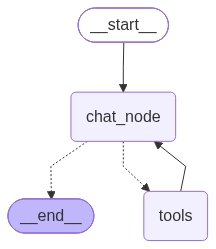

In [45]:
chatbot

In [46]:
result = chatbot.invoke({
    'messages': [
        HumanMessage(
            content=(
                "Using the pdf notes, explain what is meant by machine learning?"
            )
        )
    ]
})

NameError: name 'messages' is not defined